# Assignment 3 - Ridge and Lasso Regression 

### We are going to predict baseball salaries from performance data.  

In [25]:
# %load ../standard_import.txt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


The task in this assignment is to build models of Baseball players (only fielding players, not pitchers) salaries based on statistics.  These are real data from MLB.  
Why is this an important task - if you are a player learn what gets you paid! 
I did a little bit of clean up of the csv as we read it in. 

In [26]:
df = pd.read_csv('Hitters.csv', index_col=0)
df.index.name = 'Player'
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 322 entries, -Andy Allanson to -Willie Wilson
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    obje

The first 7 variables are from the previous season.  The variables starting with a C are career statistics.  PutOuts, Assists, and Errors are also single season statistics.  Salary is their salary.  League, Division, and NewLeague reflect where they play. 

Always deal with problems.  Non-null count tells you how many entries you have that are not missing values.  `Salary` clearly shows missing values. 

In [27]:
#Lets preemptively get rid of garbage. 
df=df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, -Alan Ashby to -Willie Wilson
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      263 non-null    int64  
 1   Hits       263 non-null    int64  
 2   HmRun      263 non-null    int64  
 3   Runs       263 non-null    int64  
 4   RBI        263 non-null    int64  
 5   Walks      263 non-null    int64  
 6   Years      263 non-null    int64  
 7   CAtBat     263 non-null    int64  
 8   CHits      263 non-null    int64  
 9   CHmRun     263 non-null    int64  
 10  CRuns      263 non-null    int64  
 11  CRBI       263 non-null    int64  
 12  CWalks     263 non-null    int64  
 13  League     263 non-null    object 
 14  Division   263 non-null    object 
 15  PutOuts    263 non-null    int64  
 16  Assists    263 non-null    int64  
 17  Errors     263 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  263 non-null    object 

In [28]:
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
Player,,,,,,,,,,,,,,,,,,,,
-Alan Ashby,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
-Alvin Davis,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
-Andre Dawson,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
-Andres Galarraga,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
-Alfredo Griffin,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A


1.  Encode and organize the data

There are 4 variables that are objects, i.e., string -  League, Division, and NewLeague.   You need to convert these into numeric variables, for example by using `get_dummies`.  

Take a moment to look at the values contained in each of these, and then make a strategy of how you want to encode them.  Keep in mind that each of them takes only two values, and you dont want to create variables that are redundant.  

NewLeague indicates the team the league is in for the new season.  Very few players change leagues, so there is not much information there.  You should remove it from the dataframe, and I assumed you did in the rest of this assignment.

The response variable is Salary.  The other variables are your predictors.  

In [29]:
df = df.drop(columns=['NewLeague'])
hit_set = pd.get_dummies(df, columns=['League', 'Division'], drop_first=True)
hit_set.head()


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W
Player,,,,,,,,,,,,,,,,,,,
-Alan Ashby,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,True,True
-Alvin Davis,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,False,True
-Andre Dawson,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,True,False
-Andres Galarraga,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,True,False
-Alfredo Griffin,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,750.0,False,True


2.  Its useful to do some exploratory data analysis.  
    First, visualize just the single season statistics. The first 7 columns in the dataframe from contain the single season statistics.  A pairplot would be a useful idea. You should immediately see that some of these variables are highly correlated. 

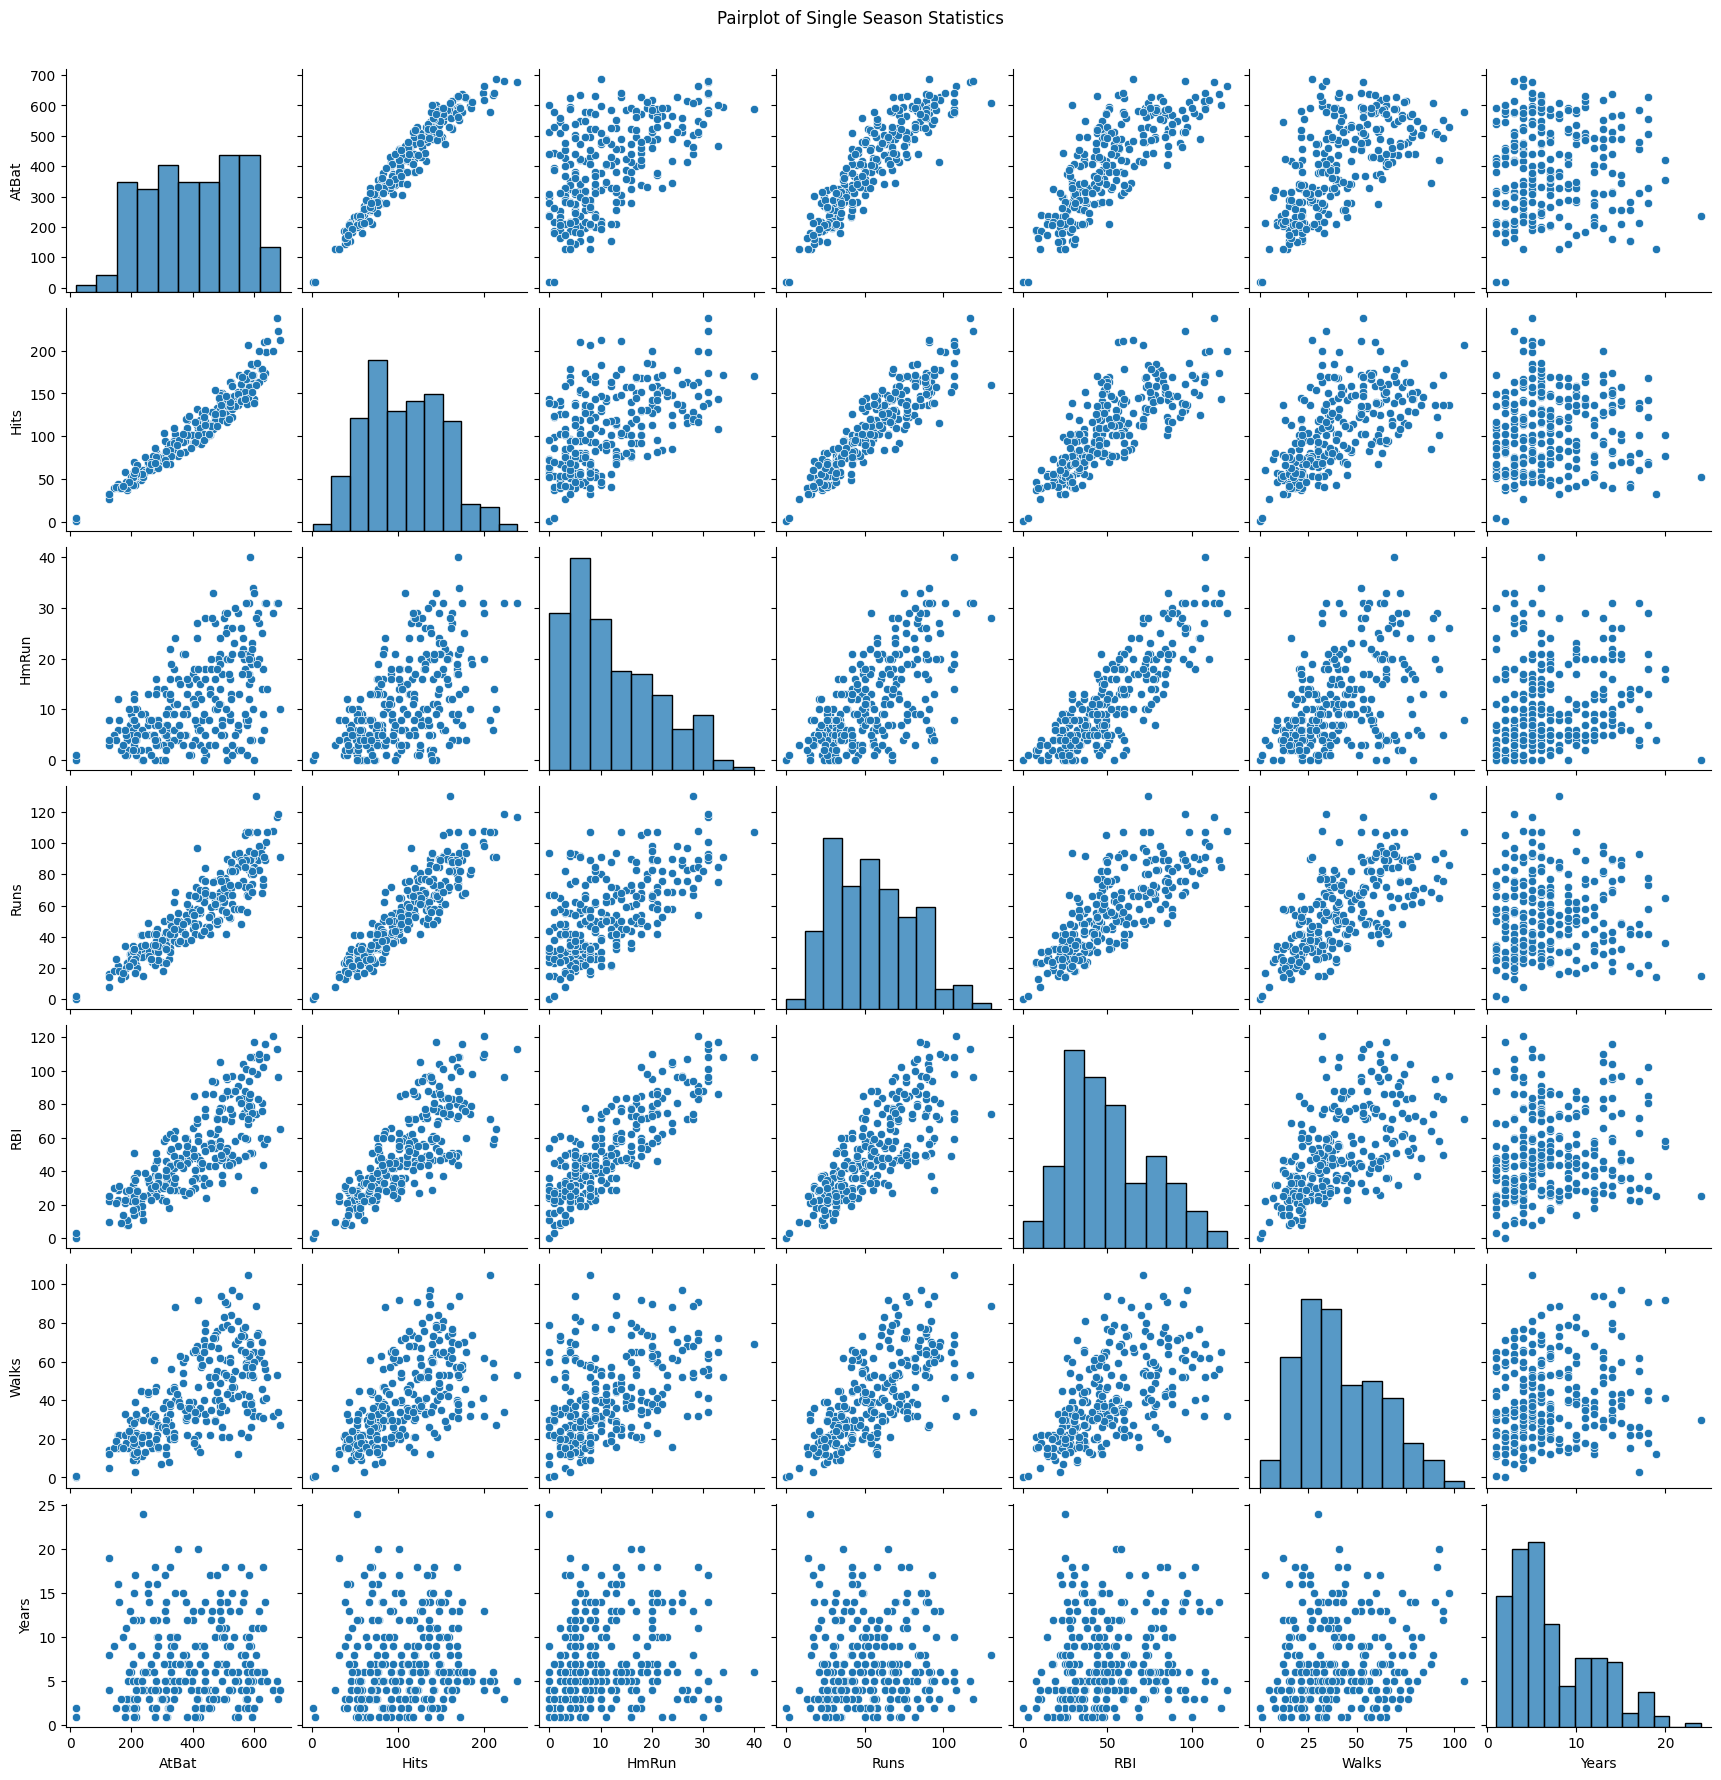

In [30]:
single_season_stats = hit_set.iloc[:, :7]

# Create a pairplot to visualize correlations
sns.pairplot(single_season_stats)
plt.suptitle('Pairplot of Single Season Statistics', y=1.02)
plt.show()


Make a heatmap showing the correlations between all the variables.  This will not work unless you have converted it all into dummy variables 

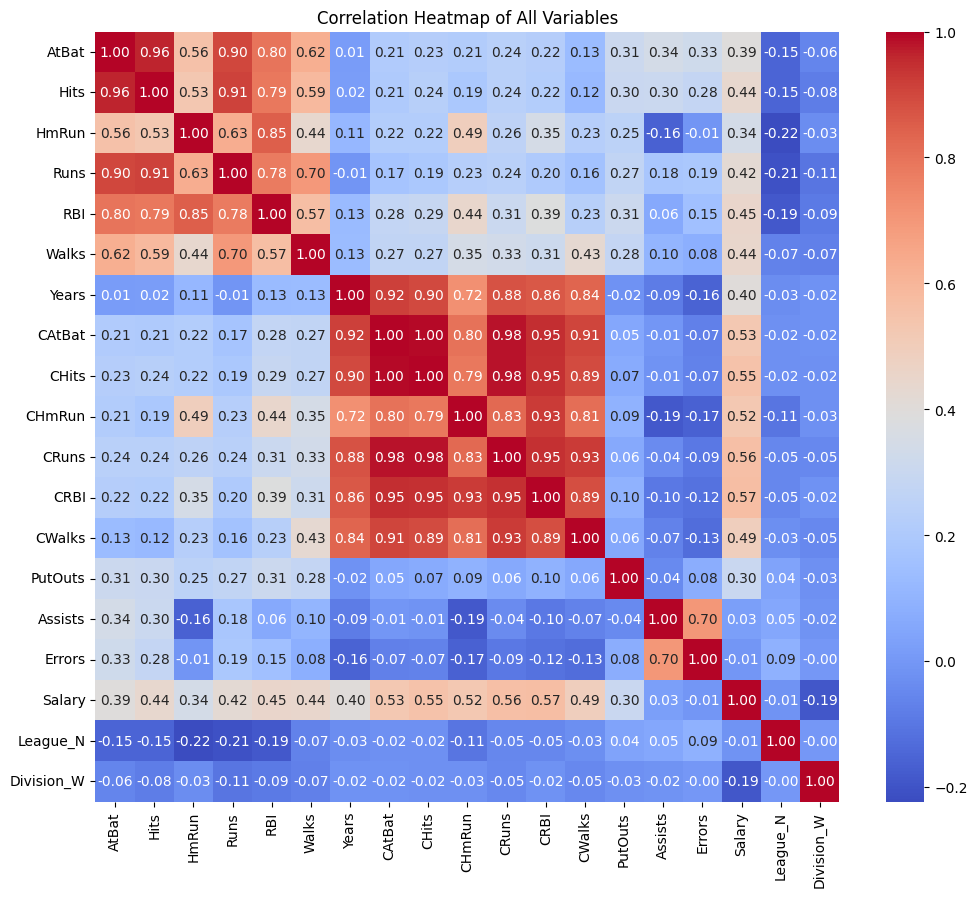

In [31]:
corr_matrix = hit_set.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap of All Variables")
plt.show()

Write down your impression of the data in the box below   What variables are highly correlated?  Are the single season statistics and career statistics highly correlated? What are some candidate variables that could explain salary? 

Some of the highly correlated variables were the single season hitting stats like AtBat, Hits, HMRun, Runs, and RBI, as well as the Career Hitting Stats like CAtBat, CHits, CHmRun, CRuns, and CRBI. The career statistics also show high correlations with the years. And Errors were also correlated strongly with Assists.

Single Season and Career statistics are highly correlated, like Hits vs. CHits (0.92), whihc shows that more recent performance shows longer-term ability.

Some Candidate Variables that explain salary are CRBI, CRuns, and CHits. These show that career statistics may be better predictors of salary (since teams most likely value proven long-term performance).

3.  Separate the data into test (25%) and training sets.  Also separate the response variable (salary) into a separate variable y, and the predictors into a separate variable X.  Use StandardScaler to scale the predictors.   Whether you choose the scale the response variable is somewhat arbitrary.  If you dont, you will get a model that predicts actual salaries and has an intercept.  For this exercise lets do it that way. 

- Split the data into training and test sets 

In [32]:
X = hit_set.drop(columns=['Salary'])
y = hit_set['Salary']

# split training (75%) + test (25%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"Training set: X_train shape = {X_train_scaled.shape}, y_train shape = {y_train.shape}")
print(f"Test set: X_test shape = {X_test_scaled.shape}, y_test shape = {y_test.shape}")
print(f"\nSalary (y) is NOT scaled - predictions will be in actual dollar amounts")

Training set: X_train shape = (197, 18), y_train shape = (197,)
Test set: X_test shape = (66, 18), y_test shape = (66,)

Salary (y) is NOT scaled - predictions will be in actual dollar amounts


- Build a standard scaler model from the training set and apply to training and test sets.  

In [33]:

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

 
print("Training set - Mean and Std Dev after scaling:")
print(X_train_scaled.mean())
print(X_train_scaled.std())
print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Training set - Mean and Std Dev after scaling:
AtBat         1.572346e-16
Hits          1.442726e-16
HmRun        -1.352556e-17
Runs         -3.381390e-17
RBI           4.959372e-17
Walks        -1.600525e-16
Years        -3.606816e-17
CAtBat       -1.803408e-17
CHits         1.803408e-17
CHmRun       -7.213632e-17
CRuns        -9.017040e-18
CRBI          8.115336e-17
CWalks        9.017040e-18
PutOuts       6.086502e-17
Assists      -4.508520e-17
Errors       -1.036960e-16
League_N     -1.803408e-17
Division_W   -9.017040e-18
dtype: float64
AtBat         1.002548
Hits          1.002548
HmRun         1.002548
Runs          1.002548
RBI           1.002548
Walks         1.002548
Years         1.002548
CAtBat        1.002548
CHits         1.002548
CHmRun        1.002548
CRuns         1.002548
CRBI          1.002548
CWalks        1.002548
PutOuts       1.002548
Assists       1.002548
Errors        1.002548
League_N      1.002548
Division_W    1.002548
dtype: float64

X_train_scaled shape: 

4.  Fit a model using OLS (`LinearRegression`).  Quantify how it fits the data in the test set by computing $r^2$.  Make a scatter plot showing the predicted salaries against the actual salaries in the test set. Make a bar plot showing the regression coefficients (`.coef_`) on each predictor. In the empty markdown box, write down how you would describe the model. 

## Multiple Linear Regression 

In [34]:
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)
y_pred_test = ols_model.predict(X_test_scaled)

r2_test = ols_model.score(X_test_scaled, y_test)
print(f"Test Set R-squared: {r2_test:.4f}")
print(f"Intercept: {ols_model.intercept_:.2f}")

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"Test Set RMSE: ${rmse_test:.2f}")


Test Set R-squared: 0.4128
Intercept: 543.48
Test Set RMSE: $356.52


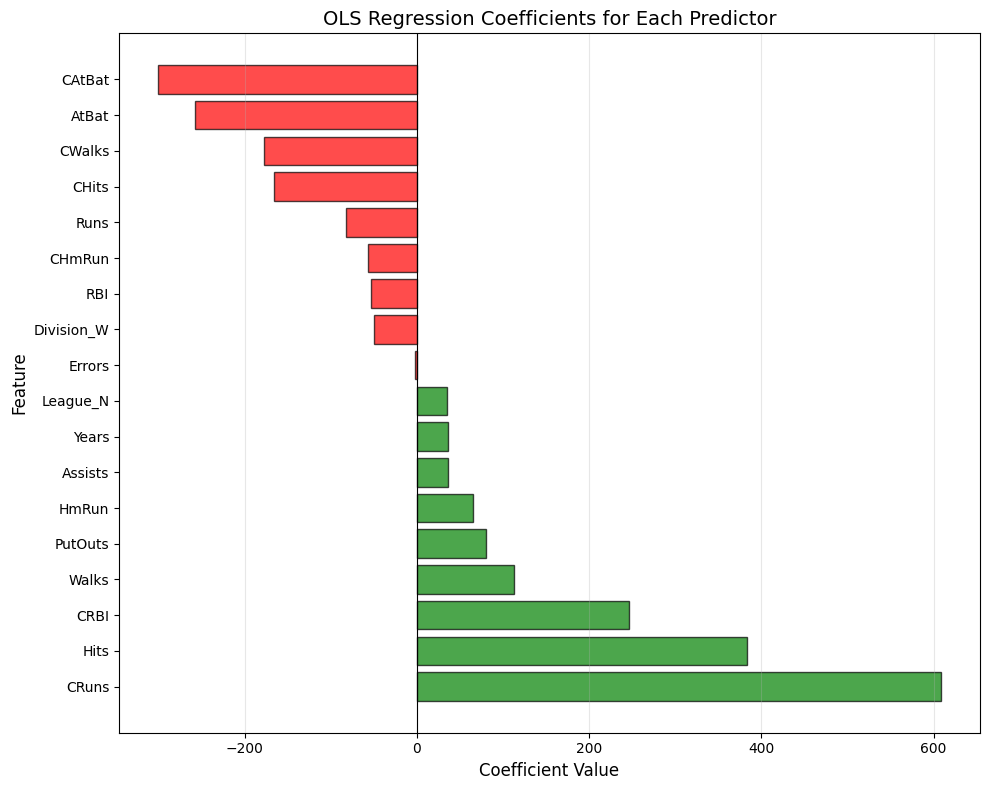


Regression Coefficients:
   Feature  Coefficient
     CRuns   608.355136
      Hits   383.389040
      CRBI   246.480448
     Walks   112.734393
   PutOuts    80.212157
     HmRun    65.280817
   Assists    36.718526
     Years    36.172489
  League_N    35.535276
    Errors    -1.973888
Division_W   -49.873669
       RBI   -52.997984
    CHmRun   -56.230592
      Runs   -81.844494
     CHits  -165.780305
    CWalks  -177.178873
     AtBat  -257.630258
    CAtBat  -300.292755


In [35]:

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': ols_model.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
colors = ['green' if c > 0 else 'red' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('OLS Regression Coefficients for Each Predictor', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nRegression Coefficients:")
print(coefficients.to_string(index=False))

I would describe the plot as showing runs scored and current season hitting performance as the primary influences/predictors on salary.

Discuss your results here.  What do you think are the most important predictors.  What does it mean if the $\beta$ is positive versus negative.  

CRuns, Hits and CRBI are the most important predictors. Having a positive beta means that it shows a  increase in salary, as opposed to a  decrease.

5.  Fit a model using Ridge Regression with cross validation.
* The `RidgeCV()` function has an $\alpha$ argument that is $\lambda$ from the lecture notes used to tune the model.
* `RidgeCV()` requires a range of value of $\alpha$ to be specified. The selected $\alpha$ will make use of cross-validation.  
* $\alpha$  = 0 is equivalent to the Least Squares solution, but it is not recommended to you actually set $\alpha$ = 0 so avoid that.  
* We expect the coefficient estimates to be much smaller, in terms of $L_2$ norm, when a large value of $\alpha$ is used,
* A very large $\alpha$ has tiny coefficients and and the model is dominated by the intercept. 
* By default `RidgeCV()` performs generalized cross-validation(essentially Leave one-out CV),
* This can be changed using the argument `cv`.

        alphas = 10**np.linspace(5,-5,20)
        ridgecv = RidgeCV(alphas = alphas,cv = 5) # 5-fold cross validation
* the best value of alpha (over the range tested) is in `ridgecv.alpha_`
* Evaluate the model by predicting the test data  


In [36]:

alphas = 10**np.linspace(5, -5, 20)



ridgecv = RidgeCV(alphas=alphas, cv=5)
ridgecv.fit(X_train_scaled, y_train)

print(f"\nBest alpha selected by cross-validation: {ridgecv.alpha_:.4f}")


y_pred_ridge = ridgecv.predict(X_test_scaled)

# calculate R-squared on test set
r2_ridge = ridgecv.score(X_test_scaled, y_test)
print(f"Ridge Test Set R-squared: {r2_ridge:.4f}")
print(f"OLS Test Set R-squared: {r2_test:.4f} (for comparison)")

# calculate RMSE
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
print(f"\nRidge Test Set RMSE: ${rmse_ridge:.2f}")
print(f"OLS Test Set RMSE: ${rmse_test:.2f} (for comparison)")






Best alpha selected by cross-validation: 233.5721
Ridge Test Set R-squared: 0.3064
OLS Test Set R-squared: 0.4128 (for comparison)

Ridge Test Set RMSE: $387.50
OLS Test Set RMSE: $356.52 (for comparison)


Make a scatter plot of the predicted salaries versus the actual salaries. Make a bar graph of the weights on the coefficients. 


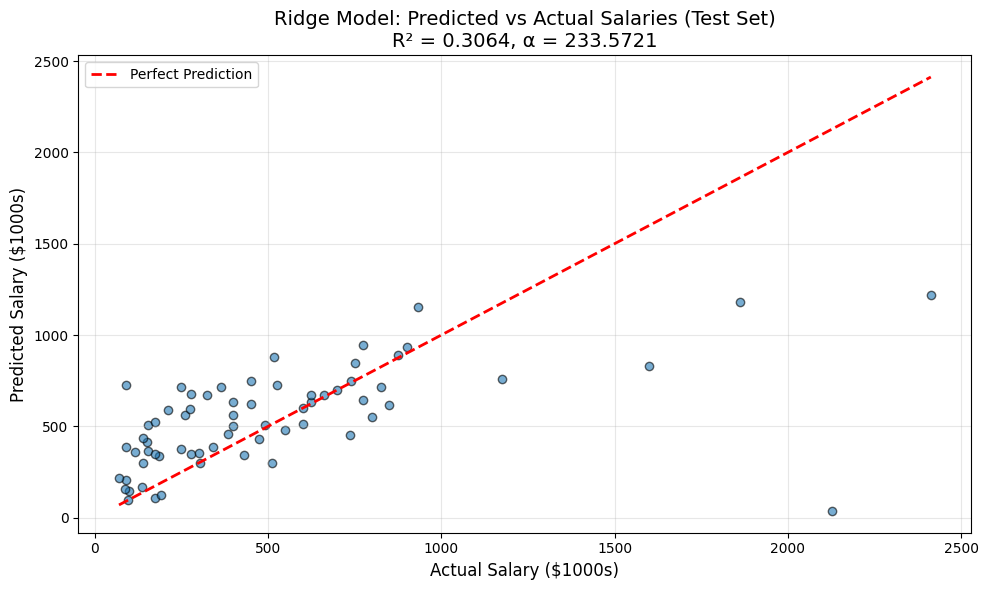


L2 Norm of Ridge coefficients: 109.92
L2 Norm of OLS coefficients: 914.19
Ridge coefficients are 8.32x smaller in L2 norm


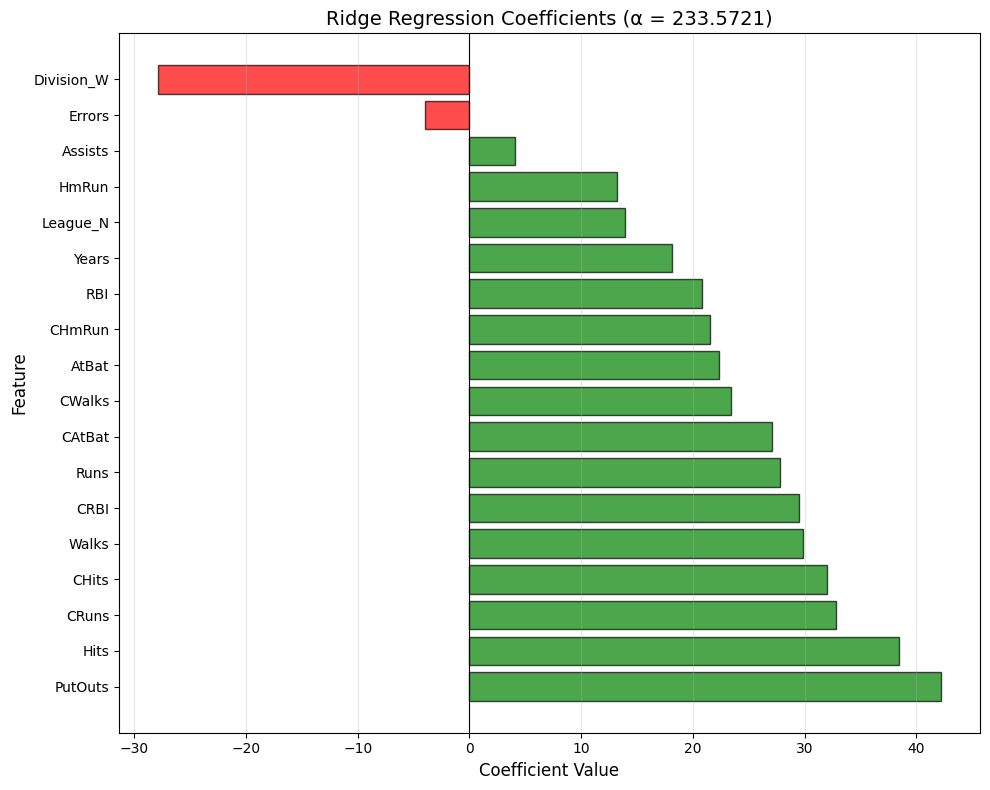

In [37]:
# Scatter plot: Ridge Predicted vs Actual Salaries
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Salary ($1000s)', fontsize=12)
plt.ylabel('Predicted Salary ($1000s)', fontsize=12)
plt.title(f'Ridge Model: Predicted vs Actual Salaries (Test Set)\nR² = {r2_ridge:.4f}, α = {ridgecv.alpha_:.4f}', 
          fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compare Ridge coefficients to OLS coefficients
ridge_coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Ridge_Coefficient': ridgecv.coef_,
    'OLS_Coefficient': ols_model.coef_
}).sort_values('Ridge_Coefficient', ascending=False)

# Calculate L2 norms
ridge_l2_norm = np.sqrt(np.sum(ridgecv.coef_**2))
ols_l2_norm = np.sqrt(np.sum(ols_model.coef_**2))
print(f"\nL2 Norm of Ridge coefficients: {ridge_l2_norm:.2f}")
print(f"L2 Norm of OLS coefficients: {ols_l2_norm:.2f}")
print(f"Ridge coefficients are {ols_l2_norm/ridge_l2_norm:.2f}x smaller in L2 norm")

# bar plot
plt.figure(figsize=(10, 8))
colors = ['green' if c > 0 else 'red' for c in ridge_coefs['Ridge_Coefficient']]
plt.barh(ridge_coefs['Feature'], ridge_coefs['Ridge_Coefficient'], 
         color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Ridge Regression Coefficients (α = {ridgecv.alpha_:.4f})', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


5.  Fit a model using LASSO Regression with cross validation. Use `LassoCV` with the same range of alpha values.  (This is not strictly required.  Typically you should test more small values of alpha)

In [ ]:

alphas = 10**np.linspace(5, -5, 20)
lassocv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lassocv.fit(X_train_scaled, y_train)

print(f"\nBest alpha selected by cross-validation: {lassocv.alpha_:.4f}")

y_pred_lasso = lassocv.predict(X_test_scaled)


r2_lasso = lassocv.score(X_test_scaled, y_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print(f"\nLASSO Test Set R-squared: {r2_lasso:.4f}")
print(f"Ridge Test Set R-squared: {r2_ridge:.4f}")
print(f"OLS Test Set R-squared: {r2_test:.4f}")

print(f"\nLASSO Test Set RMSE: ${rmse_lasso:.2f}")
print(f"Ridge Test Set RMSE: ${rmse_ridge:.2f}")
print(f"OLS Test Set RMSE: ${rmse_test:.2f}")

n_nonzero = np.sum(lassocv.coef_ != 0)
print(f"\nNumber of non-zero coefficients: {n_nonzero} out of {len(lassocv.coef_)}")
print(f"LASSO eliminated {len(lassocv.coef_) - n_nonzero} features")

Testing 20 alpha values ranging from 0.000010 to 100000.0

Best alpha selected by cross-validation: 20.6914

LASSO Test Set R-squared: 0.3302
Ridge Test Set R-squared: 0.3064
OLS Test Set R-squared: 0.4128

LASSO Test Set RMSE: $380.79
Ridge Test Set RMSE: $387.50
OLS Test Set RMSE: $356.52

Number of non-zero coefficients: 7 out of 18
LASSO eliminated 11 features


Make a scatter plot of the predicted and actual values of salary.  Make a bar graph of the Lasso coefficients (some of them are zero)

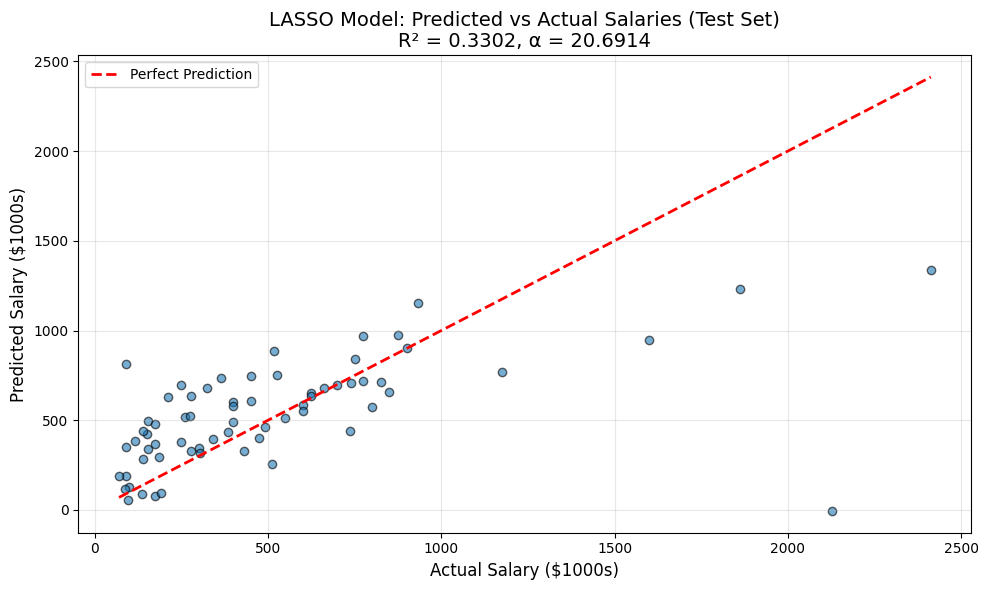

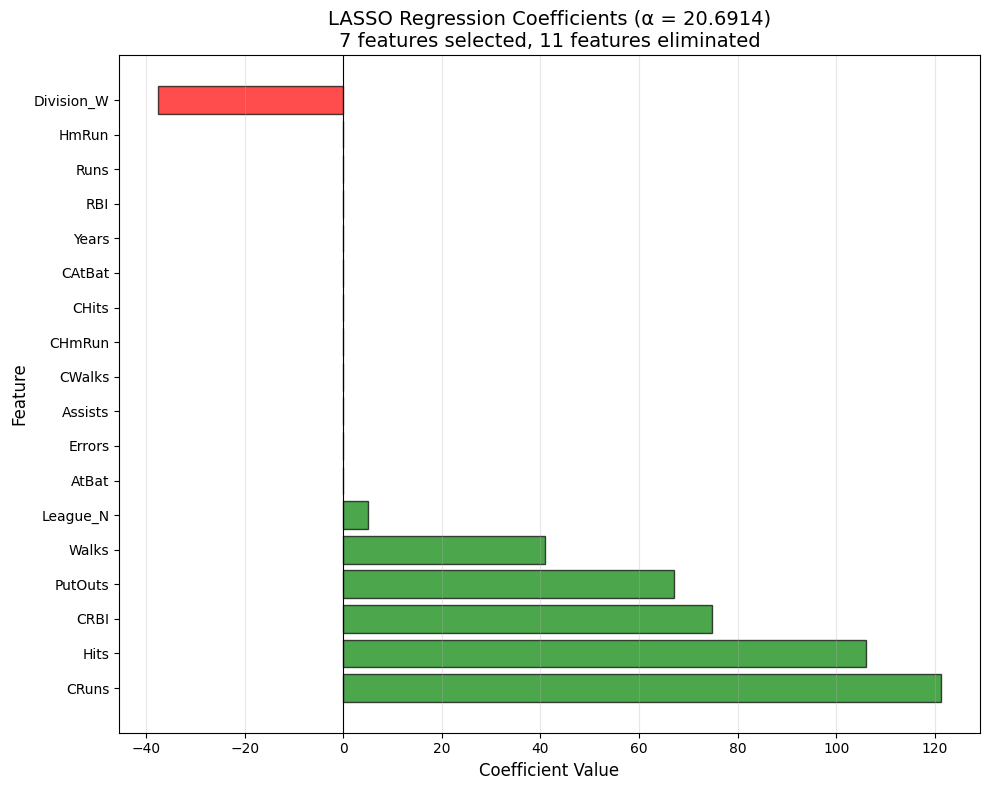

LASSO Regression Coefficients:
   Feature  Coefficient
     CRuns   121.231698
      Hits   106.104408
      CRBI    74.801573
   PutOuts    67.112868
     Walks    41.007447
  League_N     5.113014
     AtBat     0.000000
    Errors    -0.000000
   Assists    -0.000000
    CWalks     0.000000
    CHmRun     0.000000
     CHits     0.000000
    CAtBat     0.000000
     Years     0.000000
       RBI     0.000000
      Runs     0.000000
     HmRun     0.000000
Division_W   -37.540687

Features eliminated by LASSO:
  - AtBat
  - Errors
  - Assists
  - CWalks
  - CHmRun
  - CHits
  - CAtBat
  - Years
  - RBI
  - Runs
  - HmRun


In [41]:
# scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lasso, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Salary ($1000s)', fontsize=12)
plt.ylabel('Predicted Salary ($1000s)', fontsize=12)
plt.title(f'LASSO Model: Predicted vs Actual Salaries (Test Set)\nR² = {r2_lasso:.4f}, α = {lassocv.alpha_:.4f}', 
          fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# bar graph
lasso_coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lassocv.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
colors = ['green' if c > 0 else 'red' if c < 0 else 'gray' for c in lasso_coef_df['Coefficient']]
plt.barh(lasso_coef_df['Feature'], lasso_coef_df['Coefficient'], 
         color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'LASSO Regression Coefficients (α = {lassocv.alpha_:.4f})\n{n_nonzero} features selected, {len(lassocv.coef_) - n_nonzero} features eliminated', 
          fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


print("LASSO Regression Coefficients:")
print(lasso_coef_df.to_string(index=False))


eliminated = lasso_coef_df[lasso_coef_df['Coefficient'] == 0]['Feature'].tolist()
if eliminated:
    print(f"\nFeatures eliminated by LASSO:")
    for feat in eliminated:
        print(f"  - {feat}")

6. I would like you to summarizethe results of this analysis, focusing on comparing Ridge and Lasso. 
    - How did they perform in prediction? is there a big difference?
    - What are the similarities in the pattern of coefficients selected? 
    - What are the differences? 
    - Does the correlation between the predictors have an effect on the two models?
    - Are there any surprising results in either model? 
    - Which model is easier to talk about?  
    - Is East Coast bias real? 

Both models has similar r^2 and RMSE values, meaning they showed similar predictive performance. They are also similar in that CRuns and Hits were strong predictors (positive) in both models, and that the statistics over the players career was more influential than just one season.

Their difference lies in LASSO narrowing the predictors to 7 by cutting off 11 coefficients, while ridge keeps all 18 predictors and lowers all coefficients. The correlation between predictors affects both models significantly, but differently: Ridge Regression reduces variance but keeps all the variables, which makes interpretation hard. On the other hand, LASSO is much neater. Lasso is much easier to talk about

What was surprising was Division_W (West Coast) decreasing salary (damn). I think there's no strong evidence of east coast bias, but maybe a penalty/difficulty in the West